# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering

---

## 1. Import packages

In [43]:
import pandas as pd

---
## 2. Load data

In [44]:
df = pd.read_csv('./clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [45]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


---

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by your colleague to calculate the feature described above. Use this code to re-create this feature and then think about ways to build on this feature to create features with a higher predictive power.

In [46]:
price_df = pd.read_csv('price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [47]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


Now it is time to get creative and to conduct some of your own feature engineering! Have fun with it, explore different ideas and try to create as many as you can!

#Main dataframe df loaded from 'clean_data_after_eda.csv'
#Calculate total tenure in months

In [48]:
# Main dataframe df loaded from 'clean_data_after_eda.csv'
# Calculate total tenure in months
df['tenure_months'] = ((df['date_end'] - df['date_activ']).dt.days / 30.44).round(1)

# Calculate months since the last product modification
df['months_since_modification'] = ((df['date_end'] - df['date_modif_prod']).dt.days / 30.44).round(1)

In [49]:
#Merge Estelle's off-peak features
# Merge Estelle's off-peak features with the main dataframe df

df = pd.merge(df, diff, on='id', how='left')

In [50]:
#Merge new peak/mid-peak features
print(f"New shape of dataframe: {df.shape}")

New shape of dataframe: (14606, 48)


In [51]:
#Merge new peak/mid-peak features
df = pd.merge(df, peak_diff, on='id', how='left')

In [52]:
#Check newly generated features!
print(f"New shape of dataframe: {df.shape}")
df[['id', 'tenure_months', 'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power', 'months_since_modification']].head()


New shape of dataframe: (14606, 53)


,id,tenure_months,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,months_since_modification
0,24011ae4ebbe3035111d65fa7c15bc57,36.0,0.020057,3.700961,7.5
1,d29c2c54acc38ff3c0614d0a653813dd,84.3,-0.003767,0.177779,84.3
2,764c75f661154dac3a6c254cd082ea7d,72.0,-0.004670,0.177779,72.0
3,bba03439a292a1e166f80264c16191cb,72.0,-0.004547,0.177779,72.0
4,149d57cf92fc41cf94415803a877cb4b,73.8,-0.006192,0.162916,73.8


In [53]:
#Check is new columns introduced missing columns
print(df[['offpeak_diff_dec_january_energy', 'tenure_months']].isnull().sum())

offpeak_diff_dec_january_energy    0
tenure_months                      0
dtype: int64


In [54]:
#Fill missing values with 0 or median where appropiate
df['offpeak_diff_dec_january_energy'] = df['offpeak_diff_dec_january_energy'].fillna(0)
df['tenure_months'] = df['tenure_months'].fillna(df['tenure_months'].median())

In [55]:
# Drop columns that shouldn't be used as predictive features
features_df = df.drop(columns=['id', 'date_activ', 'date_end', 'date_modif_prod', 'date_renewal'])

In [56]:
# Convert categorical variables into dummy/indicator variables (0 or 1)
features_df = pd.get_dummies(features_df, columns=['channel_sales', 'origin_up'], drop_first=True)

In [57]:
from sklearn.model_selection import train_test_split


In [58]:
#Separate the target variable (churn) from the features
X = features_df.drop(columns=['churn'])
Y = features_df['churn']

In [59]:
#Split 80% train and 20% test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [60]:
from sklearn.ensemble import RandomForestClassifier



In [61]:
#Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [62]:
#Train the model
# Encode string booleans and drop the date column before fitting
X_train = X_train.copy()
X_test = X_test.copy()

if 'has_gas' in X_train.columns:
    X_train['has_gas'] = X_train['has_gas'].map({'t': 1, 'f': 0}).fillna(0).astype(int)
    X_test['has_gas'] = X_test['has_gas'].map({'t': 1, 'f': 0}).fillna(0).astype(int)

if 'price_date' in X_train.columns:
    X_train = X_train.drop(columns=['price_date'])
    X_test = X_test.drop(columns=['price_date'])

model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [63]:
from sklearn.metrics import classification_report, accuracy_score
#Make predictions
y_pred = model.predict(X_test)

#Evaluate results
print(f"Accuracy: {accuracy_score(Y_test, y_pred):.2f}")
print(classification_report(Y_test, y_pred))



Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2638
           1       0.84      0.07      0.14       284

    accuracy                           0.91      2922
   macro avg       0.87      0.54      0.54      2922
weighted avg       0.90      0.91      0.87      2922



In [64]:
import numpy as np
import matplotlib.pyplot as plt


In [65]:
#Get feature importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]


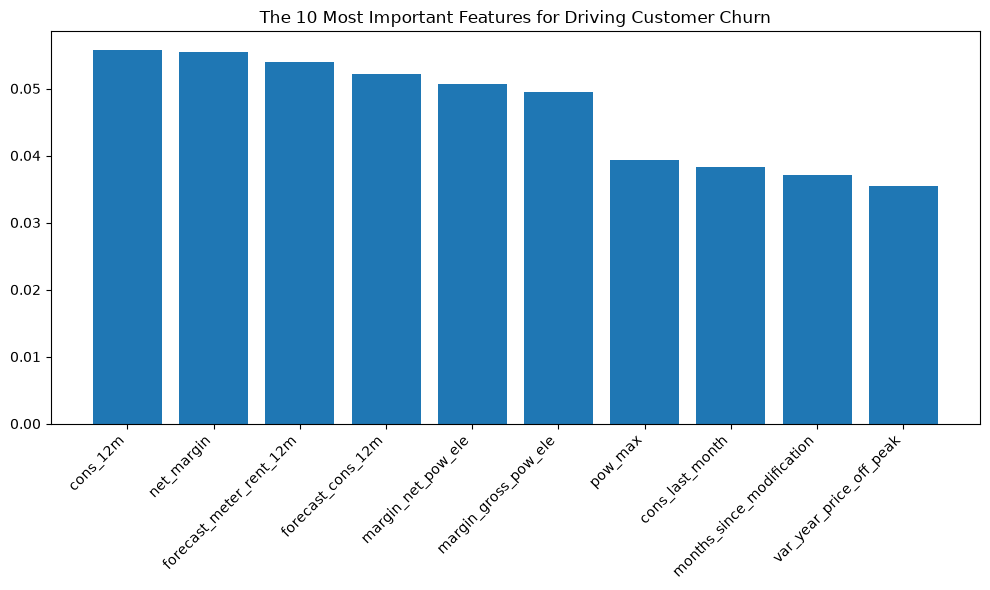

In [66]:
#Plot the 10 features
plt.figure(figsize=(10, 6))
plt.title("The 10 Most Important Features for Driving Customer Churn")
plt.bar(range(10), importances[indices][:10], align="center")
plt.xticks(range(10), [X_train.columns[i] for i in indices][:10], rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [67]:
# Save the engineered dataframe to a new CSV file
df.to_csv('clean_data_with_features.csv', index=False)
print("Data successfully saved with new features!")

Data successfully saved with new features!
